In [92]:
import numpy as np 
import matplotlib.pyplot as plt
import OrcFxAPI

In [93]:
# Pad naar je OrcaFlex modelbestand
model_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\OrcaFlex\Decay_opzet_harlequin.dat"
sim_path = r"C:\Users\verav\Desktop\Studie\Afstuderen\OrcaFlex\Decay_test1404.sim"

model = OrcFxAPI.Model(model_path)
constraint = model["decay_constraint"]
floaters = model["floaters"]
floatertype = model["Floatertype"]

In [94]:
constraint.InFrameInitialZ = constraint.InFrameInitialZ
constraint.InFrameInitialX = constraint.InFrameInitialX 
constraint.InFrameInitialY = constraint.InFrameInitialY 
constraint.InFrameInitialAzimuth = constraint.InFrameInitialAzimuth 
constraint.InFrameInitialDeclination = constraint.InFrameInitialDeclination + 5
constraint.InFrameInitialGamma = constraint.InFrameInitialGamma 






In [ ]:
floatertype.OtherDampingLinearCoeffx = 0 #surge
floatertype.OtherDampingLinearCoeffy = 0 #sway
floatertype.OtherDampingLinearCoeffz  = 0 #heav
floatertype.OtherDampingLinearCoeffRx = 0 #roll
floatertype.OtherDampingLinearCoeffRy = 0 #pitch
floatertype.OtherDampingLinearCoeffRz = 0 #yaw

floatertype.OtherDampingQuadraticCoeffx = 0 #surge
floatertype.OtherDampingQuadraticCoeffy = 0 #sway 
floatertype.OtherDampingQuadraticCoeffz = 100 #heav
floatertype.OtherDampingQuadraticCoeffRx = 0#roll
floatertype.OtherDampingQuadraticCoeffRy = 100000 #pitch
floatertype.OtherDampingQuadraticCoeffRz = 0 #yaw

In [96]:
model.RunSimulation()
model.SaveSimulation(sim_path)


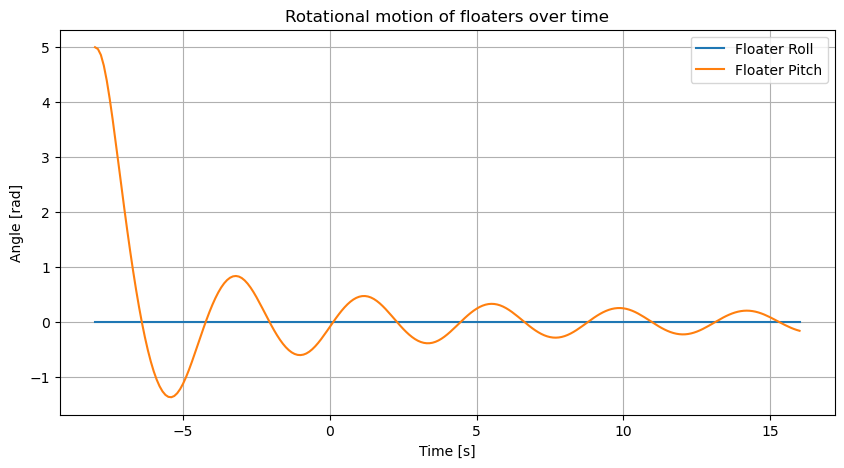

In [97]:
time = model.general.TimeHistory("Time")
roll = floaters.TimeHistory("Rotation 1")
pitch = floaters.TimeHistory("Rotation 2")



plt.figure(figsize=(10, 5))
plt.plot(time, roll, label="Floater Roll")
plt.plot(time, pitch, label="Floater Pitch")

plt.xlabel("Time [s]")
plt.ylabel("Angle [rad]")
plt.title("Rotational motion of floaters over time")
plt.grid(True)
plt.legend()
plt.show()

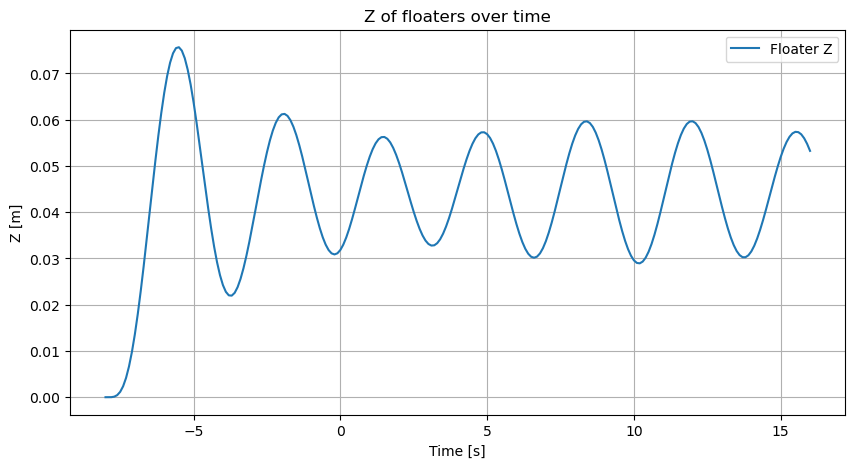

In [98]:
time = model.general.TimeHistory("Time")
z = floaters.TimeHistory("dynamic z")


plt.figure(figsize=(10, 5))
plt.plot(time, z, label="Floater Z")
plt.xlabel("Time [s]")
plt.ylabel("Z [m]")
plt.title("Z of floaters over time")
plt.grid(True)
plt.legend()
plt.show()